In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vladshmutkin/brain-mri-data/MRI_Data/val/no_tumor/no_tumor_val_0191.jpg
/kaggle/input/datasets/vladshmutkin/brain-mri-data/MRI_Data/val/no_tumor/no_tumor_val_0103.jpg
/kaggle/input/datasets/vladshmutkin/brain-mri-data/MRI_Data/val/no_tumor/no_tumor_val_0064.jpg
/kaggle/input/datasets/vladshmutkin/brain-mri-data/MRI_Data/val/no_tumor/no_tumor_val_0116.jpg
/kaggle/input/datasets/vladshmutkin/brain-mri-data/MRI_Data/val/no_tumor/no_tumor_val_0101.jpg
/kaggle/input/datasets/vladshmutkin/brain-mri-data/MRI_Data/val/no_tumor/no_tumor_val_0185.jpg
/kaggle/input/datasets/vladshmutkin/brain-mri-data/MRI_Data/val/no_tumor/no_tumor_val_0182.jpg
/kaggle/input/datasets/vladshmutkin/brain-mri-data/MRI_Data/val/no_tumor/no_tumor_val_0147.jpg
/kaggle/input/datasets/vladshmutkin/brain-mri-data/MRI_Data/val/no_tumor/no_tumor_val_0085.jpg
/kaggle/input/datasets/vladshmutkin/brain-mri-data/MRI_Data/val/no_tumor/no_tumor_val_0198.jpg
/kaggle/input/datasets/vladshmutkin/brain-mri-data

In [3]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## Модель DenseNet121

In [4]:
import torch
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os

print("Libraries imported and dataset paths defined.")

Libraries imported and dataset paths defined.


In [5]:
import os

# Показываем, что реально есть в папке input
print("Доступные датасеты:")
for dirname, _, _ in os.walk('/kaggle/input'):
    print(dirname)

Доступные датасеты:
/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/vladshmutkin
/kaggle/input/datasets/vladshmutkin/brain-mri-data
/kaggle/input/datasets/vladshmutkin/brain-mri-data/MRI_Data
/kaggle/input/datasets/vladshmutkin/brain-mri-data/MRI_Data/val
/kaggle/input/datasets/vladshmutkin/brain-mri-data/MRI_Data/val/no_tumor
/kaggle/input/datasets/vladshmutkin/brain-mri-data/MRI_Data/val/pituitary_tumor
/kaggle/input/datasets/vladshmutkin/brain-mri-data/MRI_Data/val/meningioma_tumor
/kaggle/input/datasets/vladshmutkin/brain-mri-data/MRI_Data/val/glioma_tumor
/kaggle/input/datasets/vladshmutkin/brain-mri-data/MRI_Data/test
/kaggle/input/datasets/vladshmutkin/brain-mri-data/MRI_Data/test/no_tumor
/kaggle/input/datasets/vladshmutkin/brain-mri-data/MRI_Data/test/pituitary_tumor
/kaggle/input/datasets/vladshmutkin/brain-mri-data/MRI_Data/test/meningioma_tumor
/kaggle/input/datasets/vladshmutkin/brain-mri-data/MRI_Data/test/glioma_tumor
/kaggle/input/datasets/vladshmutkin/brain

In [6]:
# Сначала узнаём размер и формат изображений

from PIL import Image

img_path = "/kaggle/input/datasets/vladshmutkin/brain-mri-data/MRI_Data/val/no_tumor"
img_name = os.listdir(img_path)[0]

img = Image.open(os.path.join(img_path, img_name))
print("Image size:", img.size)
print("Image mode:", img.mode)

Image size: (512, 512)
Image mode: RGB


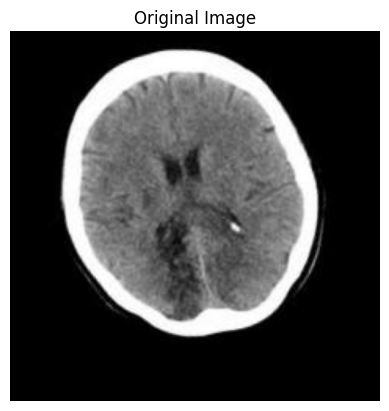

In [7]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

## Загрузка Датасетов

In [8]:
train_data_dir = "/kaggle/input/datasets/vladshmutkin/brain-mri-data/MRI_Data/train/"
val_data_dir = "/kaggle/input/datasets/vladshmutkin/brain-mri-data/MRI_Data/val/"
test_data_dir = "/kaggle/input/datasets/vladshmutkin/brain-mri-data/MRI_Data/test/"

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.ImageFolder(root=train_data_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=val_data_dir, transform=val_test_transform)
test_dataset = datasets.ImageFolder(root=test_data_dir, transform=val_test_transform)

print("Classes:", train_dataset.classes)

Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [9]:
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 8000
Val size: 1000
Test size: 1000


In [10]:
# DataLoader’ы
from torch.utils.data import DataLoader

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

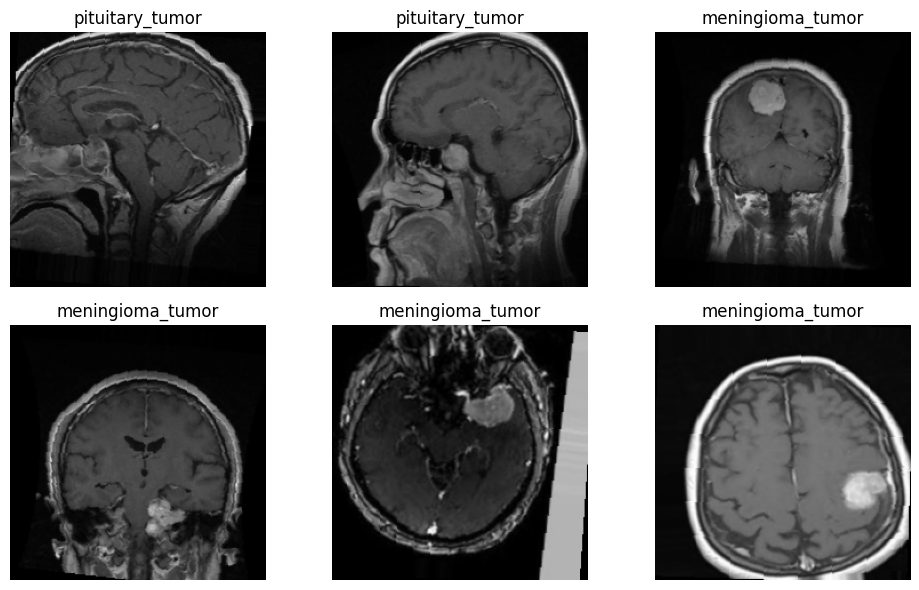

In [11]:
import torch

def imshow(tensor):
    tensor = tensor.permute(1, 2, 0)  # C,H,W → H,W,C
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    tensor = tensor * std + mean
    tensor = torch.clamp(tensor, 0, 1)
    plt.imshow(tensor)
    plt.axis("off")

images, labels = next(iter(train_loader))

plt.figure(figsize=(10,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    imshow(images[i])
    plt.title(train_dataset.classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Построение модели DenseNet121

In [14]:
# модуль, где определены слои для нейронных сетей
import torch.nn as nn
# модуль, где определены активации для слоев нейронных сетей
import torch.nn.functional as F

In [15]:
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

class BrainTumorDenseNet(nn.Module):
    def __init__(self, num_classes):
        super(BrainTumorDenseNet, self).__init__()

        # Загружаем предобученную DenseNet121
        self.model = models.densenet121(pretrained=True)

        # Количество входных признаков в классификаторе
        in_features = self.model.classifier.in_features

        # Заменяем последний слой под нашу задачу
        self.model.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [16]:
num_classes = len(train_dataset.classes)

model = BrainTumorDenseNet(num_classes)
print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 163MB/s] 


BrainTumorDenseNet(
  (model): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1): BatchNorm2d(96, eps=1e-05, mom

## Перенесем нейросеть на GPU¶

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

## Заморозка слоёв. transfer learning. feature extractor

In [20]:
for param in model.model.features.parameters():
    param.requires_grad = False

📌 Что это значит
👉 ты говоришь PyTorch:

“НЕ обновляй веса этих слоёв при обучении”

🧠 Как работает обучение в целом
Во время обучения:

forward pass → считаем output
считаем loss
backward pass → считаем градиенты
optimizer обновляет веса
❗ Ключевой момент:
param.requires_grad = False

👉 означает:
❌ градиенты НЕ считаются
❌ веса НЕ обновляются


📊 3. Что именно ты замораживаешь
model.model.features

👉 это: model.model.features

вся сверточная часть DenseNet (feature extractor)

👉 остаётся обучаемым только:

model.model.classifier

❌ DenseNet (features) НЕ обучается
✅ обучается только classifier

## Training loop (train + validation)

In [21]:
import torch.optim as optim

# Функция потерь
criterion = nn.CrossEntropyLoss()

# обучаем ТОЛЬКО классификатор
optimizer = optim.Adam(model.model.classifier.parameters(), lr=0.001)

In [22]:
import torch

def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=10):

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):

        # ===================== TRAIN =====================
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            # обнуляем градиенты
            optimizer.zero_grad()

            # forward
            outputs = model(images)
            loss = criterion(outputs, labels)

            # backward
            loss.backward()
            optimizer.step()

            # статистика
            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        # ===================== VALIDATION =====================
        model.eval()

        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(val_loader)
        val_acc = correct / total

        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        # ===================== LOG =====================
        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
        print("-" * 40)

    return train_losses, val_losses, train_accuracies, val_accuracies

In [23]:
num_epochs = 10

train_losses, val_losses, train_accs, val_accs = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=num_epochs
)

Epoch [1/10]
Train Loss: 0.6634 | Train Acc: 0.7504
Val   Loss: 0.4692 | Val   Acc: 0.8440
----------------------------------------
Epoch [2/10]
Train Loss: 0.4515 | Train Acc: 0.8355
Val   Loss: 0.3941 | Val   Acc: 0.8460
----------------------------------------
Epoch [3/10]
Train Loss: 0.4033 | Train Acc: 0.8480
Val   Loss: 0.3196 | Val   Acc: 0.8850
----------------------------------------
Epoch [4/10]
Train Loss: 0.3868 | Train Acc: 0.8565
Val   Loss: 0.3170 | Val   Acc: 0.8820
----------------------------------------
Epoch [5/10]
Train Loss: 0.3631 | Train Acc: 0.8629
Val   Loss: 0.3070 | Val   Acc: 0.8860
----------------------------------------
Epoch [6/10]
Train Loss: 0.3678 | Train Acc: 0.8632
Val   Loss: 0.3066 | Val   Acc: 0.8910
----------------------------------------
Epoch [7/10]
Train Loss: 0.3461 | Train Acc: 0.8698
Val   Loss: 0.3071 | Val   Acc: 0.8890
----------------------------------------
Epoch [8/10]
Train Loss: 0.3289 | Train Acc: 0.8769
Val   Loss: 0.2879 | Val

### Best Validation Accuracy: 0.8930

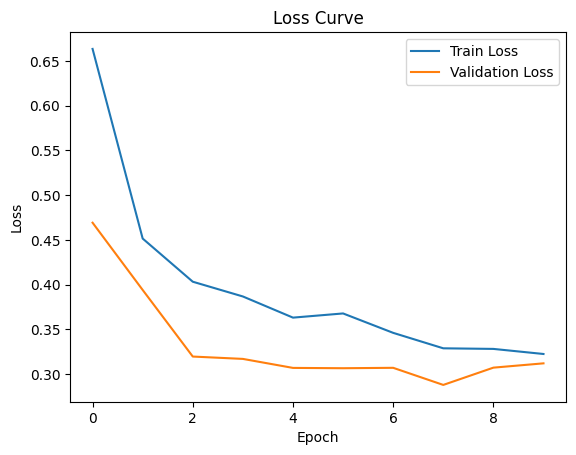

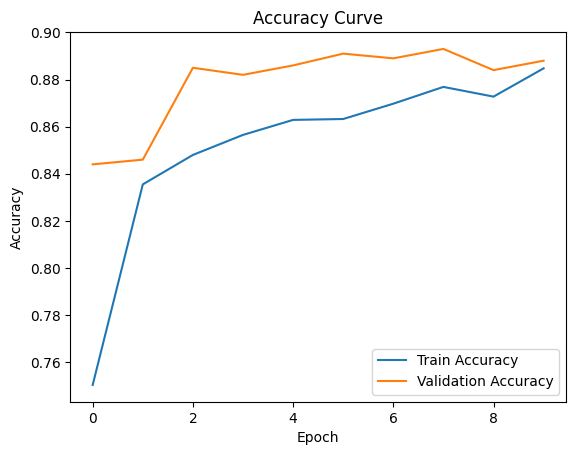

In [24]:
import matplotlib.pyplot as plt

# --- Loss ---
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

# --- Accuracy ---
plt.figure()
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

🧠 2. Как понять переобучение

Смотри на графики:

## 🔴 Переобучение (overfitting)

### Если:

### train_acc → растёт (например 0.98)
### val_acc → стоит или падает (0.88–0.89)

### 👉 значит модель “запомнила” train

🔵 Недообучение (underfitting)

Если:

и train_acc и val_acc низкие (например ~0.8)

👉 модель не доучилась

🟢 Нормально

Если:

train ≈ val
обе растут

## Здесь пошло переобучение

## Fine-Tuning

### 🔥 3. Теперь делаем Fine-Tuning

### Вот где начнётся магия.

### ✅ Стратегия (очень важная)

### Не размораживаем ВСЁ сразу ❌
### 👉 размораживаем последние слои

### 🔧 Шаг 1. Разморозим часть DenseNet

In [25]:
# сначала всё заморожено
for param in model.model.features.parameters():
    param.requires_grad = False

# размораживаем ПОСЛЕДНИЙ dense block
for param in model.model.features.denseblock4.parameters():
    param.requires_grad = True

🧠 Почему именно denseblock4

DenseNet структура:

denseblock1 → базовые признаки
denseblock2
denseblock3
denseblock4 → сложные признаки

👉 мы хотим адаптировать высокоуровневые признаки под MRI

In [26]:
# 🔧 Шаг 2. Новый optimizer (очень важно)

# Теперь обучаются:

# classifier
# часть features

# 👉 нужно уменьшить learning rate

# 💡 Почему 1e-4
# pretrained веса нельзя сильно менять
# иначе “сломаем” модель

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

📌 1. Почему используется
filter(lambda p: p.requires_grad, model.parameters())
🧠 Что это вообще делает

👉 это фильтр:

lambda p: p.requires_grad

означает:

“оставь только те параметры, у которых requires_grad = True”

👉 теперь optimizer видит только:

classifier
размороженные слои (например denseblock4)

## Дообучение

In [27]:
train_losses, val_losses, train_accs, val_accs = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    num_epochs=5
)

Epoch [1/5]
Train Loss: 0.2055 | Train Acc: 0.9243
Val   Loss: 0.1020 | Val   Acc: 0.9660
----------------------------------------
Epoch [2/5]
Train Loss: 0.1005 | Train Acc: 0.9647
Val   Loss: 0.0733 | Val   Acc: 0.9740
----------------------------------------
Epoch [3/5]
Train Loss: 0.0654 | Train Acc: 0.9774
Val   Loss: 0.0420 | Val   Acc: 0.9830
----------------------------------------
Epoch [4/5]
Train Loss: 0.0504 | Train Acc: 0.9825
Val   Loss: 0.0298 | Val   Acc: 0.9880
----------------------------------------
Epoch [5/5]
Train Loss: 0.0363 | Train Acc: 0.9874
Val   Loss: 0.0314 | Val   Acc: 0.9860
----------------------------------------


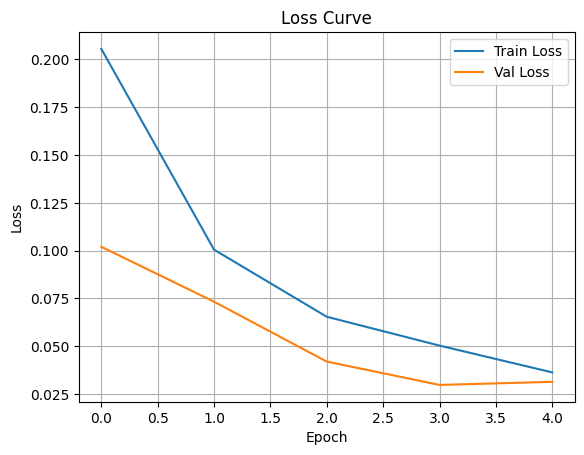

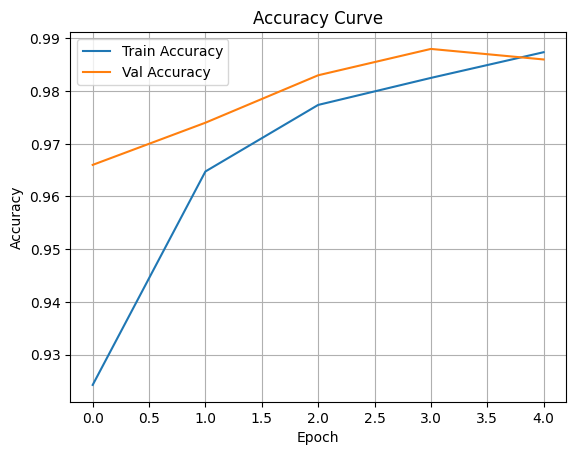

In [29]:
import matplotlib.pyplot as plt

def plot_training_history(train_losses, val_losses, train_accs, val_accs):

    # Loss
    plt.figure()
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Curve')
    plt.legend()
    plt.grid()
    plt.show()

    # Accuracy
    plt.figure()
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(val_accs, label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Curve')
    plt.legend()
    plt.grid()
    plt.show()

plot_training_history(train_losses, val_losses, train_accs, val_accs)

## Проверка на тестовом датасете

In [30]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total

print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9900


## Построение Confusion Matrix

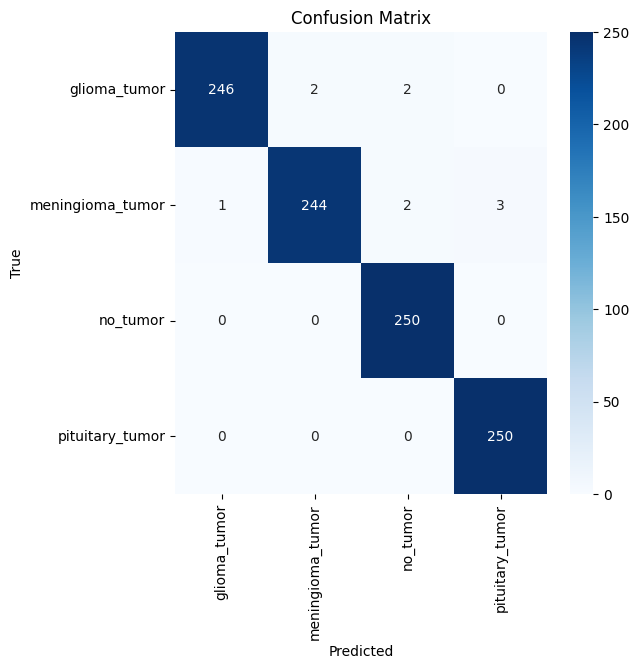

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

y_true = []
y_pred = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())


import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [33]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=train_dataset.classes
)

print(report)

                  precision    recall  f1-score   support

    glioma_tumor       1.00      0.98      0.99       250
meningioma_tumor       0.99      0.98      0.98       250
        no_tumor       0.98      1.00      0.99       250
 pituitary_tumor       0.99      1.00      0.99       250

        accuracy                           0.99      1000
       macro avg       0.99      0.99      0.99      1000
    weighted avg       0.99      0.99      0.99      1000



In [34]:
torch.save(model.state_dict(), "MRI_DenseNet121_99%ACC.pth")

In [36]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 61.9 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=0b031631a29148208cfbdd9894c651d52ff50aa5305184cd83f49bc69b3ac330
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


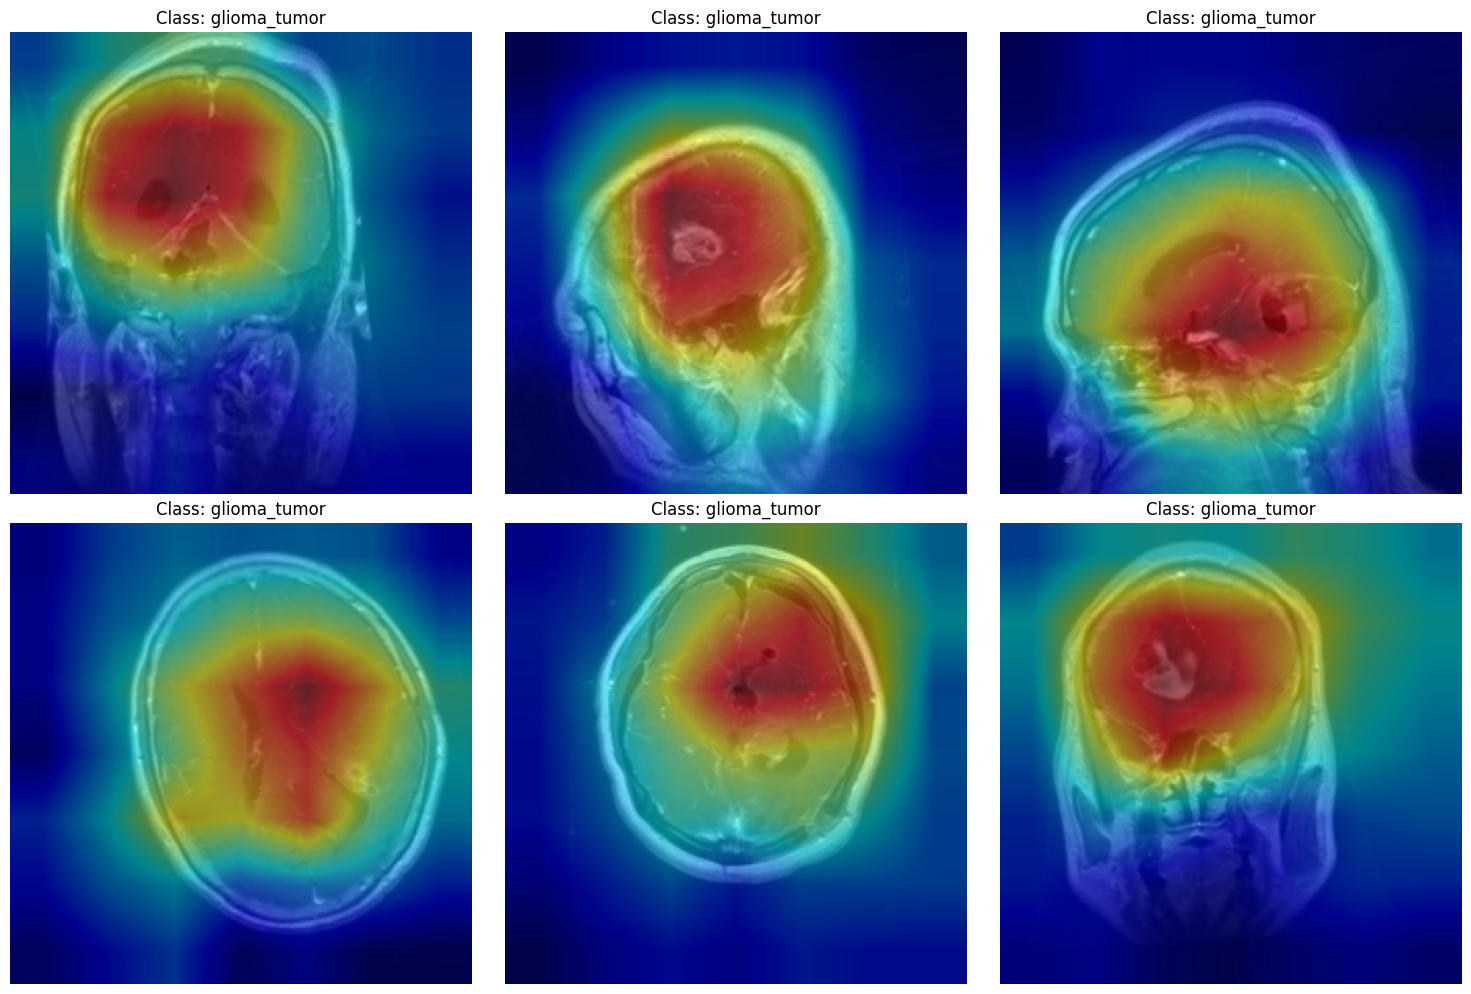

In [38]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import cv2

import matplotlib.pyplot as plt

num_images = 6  # сколько показать

images, labels = next(iter(test_loader))

plt.figure(figsize=(15, 10))

for i in range(num_images):
    input_tensor = images[i].unsqueeze(0).to(device)

    # CAM
    grayscale_cam = cam(input_tensor=input_tensor)[0]

    # подготовка изображения
    img = images[i].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())

    visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)

    plt.subplot(2, 3, i + 1)
    plt.imshow(visualization)
    plt.title(f"Class: {train_dataset.classes[labels[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()